# Baseline V0: Raw Features + LightGBM (no feature engineering)

## Split architecture
```
orig_full_train.parquet (590,540 rows)
    └── data_loader.save_processed() → train.parquet (354,324 rows, 60%)  ← training
                                     → val.parquet   (118,108 rows, 20%)  ← early stopping + dev evaluation
                                     → test.parquet  (118,108 rows, 20%)  ← frozen TEST (final evaluation only)
```

## Evaluation strategy
- **val.parquet** — used for early stopping + development metrics (compare versions, tune threshold)
- **test.parquet** — used once at the end for final unbiased metrics


In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.append("../src")  # shared: config, data_loader
sys.path.append("../v0")   # v0 modules: preproc_v0, train_v0, evaluate_v0

from data_loader import load_processed
from config import PROJECT_ROOT, TARGET, NON_FEATURE_COLS, TIME_COL


## Step 1 — Load Data

In [2]:
train, val, test = load_processed(PROJECT_ROOT / "data")

print(f"train : {train.shape[0]:,} rows | fraud: {train['isFraud'].mean():.4%}")
print(f"val   : {val.shape[0]:,} rows | fraud: {val['isFraud'].mean():.4%}  <- early stopping + dev eval")
print(f"test  : {test.shape[0]:,} rows | fraud: {test['isFraud'].mean():.4%}  <- frozen TEST")


>> Loading processed parquet files (train + val + test)...
   train : 354,324 rows × 439 cols (937 MB)
   val   : 118,108 rows × 439 cols (314 MB)  <- early stopping
   test  : 118,108 rows × 439 cols (314 MB)  <- frozen TEST
   Dtypes: {dtype('float32'): np.int64(399), dtype('O'): np.int64(32), dtype('int32'): np.int64(4), dtype('int64'): np.int64(2), dtype('int8'): np.int64(1), dtype('int16'): np.int64(1)}

   Train preview (top 7 rows):


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_36,id_37,id_38,DeviceType,DeviceInfo,tx_day,tx_dow,tx_hour,tx_dom,DeviceType_filled
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,None,None,None,None,None,1,1,0,2,No device info
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,None,None,None,None,None,1,1,0,2,No device info
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,None,None,None,None,None,1,1,0,2,No device info
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,None,None,None,None,None,1,1,0,2,No device info
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,1,1,0,2,mobile
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,None,None,None,None,None,1,1,0,2,No device info
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,None,None,None,None,None,1,1,0,2,No device info


train : 354,324 rows | fraud: 3.3833%
val   : 118,108 rows | fraud: 3.9041%  <- early stopping + dev eval
test  : 118,108 rows | fraud: 3.4409%  <- frozen TEST


## Step 2 — Separate Target Variable

In [3]:
# Separate target and features for all three sets
X_train = train.copy()
X_val   = val.copy()
X_test  = test.copy()

y_train = X_train.pop(TARGET).astype(int)
y_val   = X_val.pop(TARGET).astype(int)
y_test  = X_test.pop(TARGET).astype(int)

# Temporal ordering checks
assert X_train[TIME_COL].max() <= X_val[TIME_COL].min(), "Temporal order broken: train/val!"
assert X_val[TIME_COL].max() <= X_test[TIME_COL].min(),  "Temporal order broken: val/test!"

print(f"X_train : {X_train.shape} | fraud: {y_train.mean():.4%}")
print(f"X_val   : {X_val.shape}   | fraud: {y_val.mean():.4%}  <- early stopping")
print(f"X_test  : {X_test.shape}  | fraud: {y_test.mean():.4%}  <- frozen TEST")
print("Temporal ordering: OK ✓")


X_train : (354324, 438) | fraud: 3.3833%
X_val   : (118108, 438)   | fraud: 3.9041%  <- early stopping
X_test  : (118108, 438)  | fraud: 3.4409%  <- frozen TEST
Temporal ordering: OK ✓


## Step 3 — Preprocess
Fit encoding on train only — transform val and test with the same mapping.
**No data leakage.**


In [4]:
from preproc_v0 import preprocess_fit, preprocess_transform

# Fit on train — learn encoding mappings
X_train, encoding_map = preprocess_fit(X_train, cols_to_drop=NON_FEATURE_COLS)

# Transform val and test — apply same mappings (no data leakage)
X_val  = preprocess_transform(X_val,  encoding_map, cols_to_drop=NON_FEATURE_COLS)
X_test = preprocess_transform(X_test, encoding_map, cols_to_drop=NON_FEATURE_COLS)


PREPROCESSING v0 — FIT (train)
>> Encoding categorical columns (fit on train)...
   Shape before: (354324, 438)
   Found 32 categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5']...
   Encoded 32 columns
   Shape after: (354324, 438)

>> Filling missing values with -1...
   NaN before: 62,044,272 values in 341 columns
   NaN after:  0

>> Dropping non-feature columns...
   Shape before: (354324, 438)
   Dropped: ['TransactionID', 'TransactionDT']
   Not found (skipped): ['isFraud']
   Shape after: (354324, 436)

   Final shape: (354324, 436)
   Dtypes: {dtype('float32'): np.int64(399), dtype('int32'): np.int64(34), dtype('int64'): np.int64(2), dtype('int16'): np.int64(1)}
PREPROCESSING v0 — TRANSFORM (val/test)
>> Encoding categorical columns (transform)...
   Shape before: (118108, 438)
   Transformed 32 columns
   Unseen values (mapped to -2): 8,989
   Shape after: (118108, 438)

>> Filling missing values with -1...
   NaN

## Step 4 — Train LightGBM (default parameters, early stopping on val)

In [5]:
from train_v0 import train_lgbm

# Early stopping monitors val — stops when AUC stops improving
model, y_pred_val = train_lgbm(X_train, y_train, X_val, y_val)


>> Training LightGBM...
   Train: 354,324 samples x 436 features
   Val:   118,108 samples x 436 features
   Early stopping: 200 rounds
   Key params: lr=0.05, leaves=128, estimators=3000
Training until validation scores don't improve for 200 rounds
[100]	valid_0's auc: 0.920591
[200]	valid_0's auc: 0.930035
[300]	valid_0's auc: 0.93091
[400]	valid_0's auc: 0.930677
[500]	valid_0's auc: 0.930211
Early stopping, best iteration is:
[315]	valid_0's auc: 0.931409

   Best iteration: 315
   Best AUC on val: 0.931409


## Step 5 — Evaluate on Val
Development evaluation — used for comparing versions and selecting threshold.
Val was used for early stopping, but is still valid for development metrics.


VAL EVALUATION (development)
EVALUATION RESULTS
   ROC AUC:  0.931409
   PR AUC:   0.625989
   Threshold: 0.5

   Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113497
           1       0.87      0.38      0.53      4611

    accuracy                           0.97    118108
   macro avg       0.92      0.69      0.76    118108
weighted avg       0.97      0.97      0.97    118108



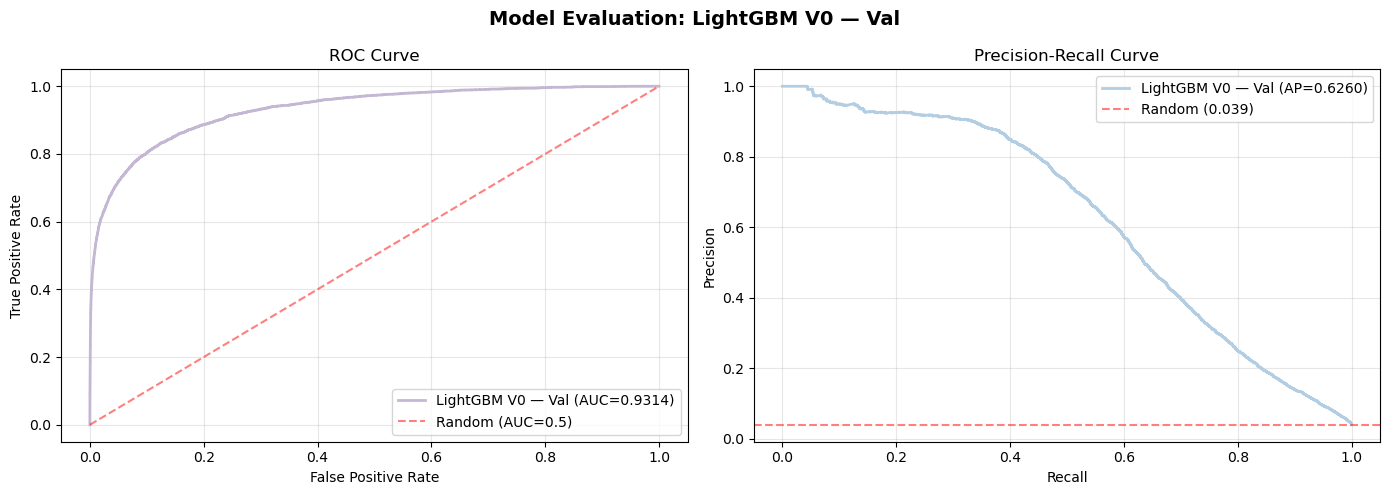

In [6]:
from evaluate_v0 import compute_metrics, plot_roc_pr

print("=" * 60)
print("VAL EVALUATION (development)")
print("=" * 60)
val_metrics = compute_metrics(y_val, y_pred_val)
plot_roc_pr(y_val, y_pred_val, model_name="LightGBM V0 — Val")


## Step 6 — Threshold Analysis on Val
Select optimal threshold on val — never on test.


In [7]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred = (y_pred_val >= t).astype(int)
    print(f"\n{'='*60}")
    print(f"Threshold: {t}  (predicted as fraud: {y_pred.sum():,})")
    print(f"{'='*60}")
    print(classification_report(y_val, y_pred, digits=3))



Threshold: 0.1  (predicted as fraud: 5,483)
              precision    recall  f1-score   support

           0      0.985     0.977     0.981    113497
           1      0.525     0.624     0.570      4611

    accuracy                          0.963    118108
   macro avg      0.755     0.801     0.776    118108
weighted avg      0.967     0.963     0.965    118108


Threshold: 0.2  (predicted as fraud: 3,427)
              precision    recall  f1-score   support

           0      0.981     0.991     0.986    113497
           1      0.699     0.519     0.596      4611

    accuracy                          0.972    118108
   macro avg      0.840     0.755     0.791    118108
weighted avg      0.970     0.972     0.971    118108


Threshold: 0.3  (predicted as fraud: 2,701)
              precision    recall  f1-score   support

           0      0.978     0.995     0.987    113497
           1      0.786     0.460     0.580      4611

    accuracy                          0.974    

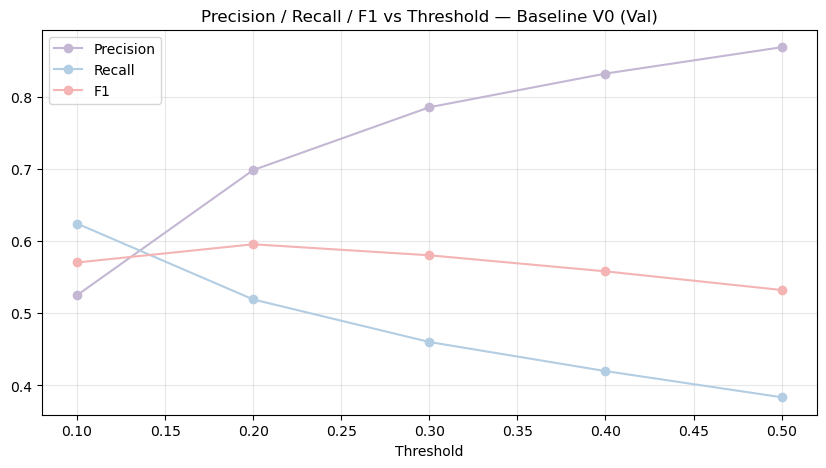

In [8]:
# Threshold visualization
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred = (y_pred_val >= t).astype(int)
    precisions.append(precision_score(y_val, y_pred))
    recalls.append(recall_score(y_val, y_pred))
    f1s.append(f1_score(y_val, y_pred))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, 'o-', label='Precision', color='#c4b7d4')
plt.plot(thresholds, recalls,   'o-', label='Recall',    color='#b3cde3')
plt.plot(thresholds, f1s,       'o-', label='F1',        color='#f4b4b4')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold — Baseline V0 (Val)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Step 7 — Feature Importance — Top 30 Features

>> Top 30 features by importance:
     1. card1                           importance: 2120
     2. card2                           importance: 1727
     3. tx_day                          importance: 1534
     4. addr1                           importance: 1309
     5. TransactionAmt                  importance: 1242
     6. C13                             importance: 928
     7. D10                             importance: 809
     8. D1                              importance: 803
     9. tx_dom                          importance: 801
    10. D15                             importance: 782
    11. P_emaildomain                   importance: 747
    12. tx_hour                         importance: 742
    13. card5                           importance: 697
    14. D2                              importance: 669
    15. D4                              importance: 619
    16. dist1                           importance: 614
    17. C1                              importance: 582
    18. i

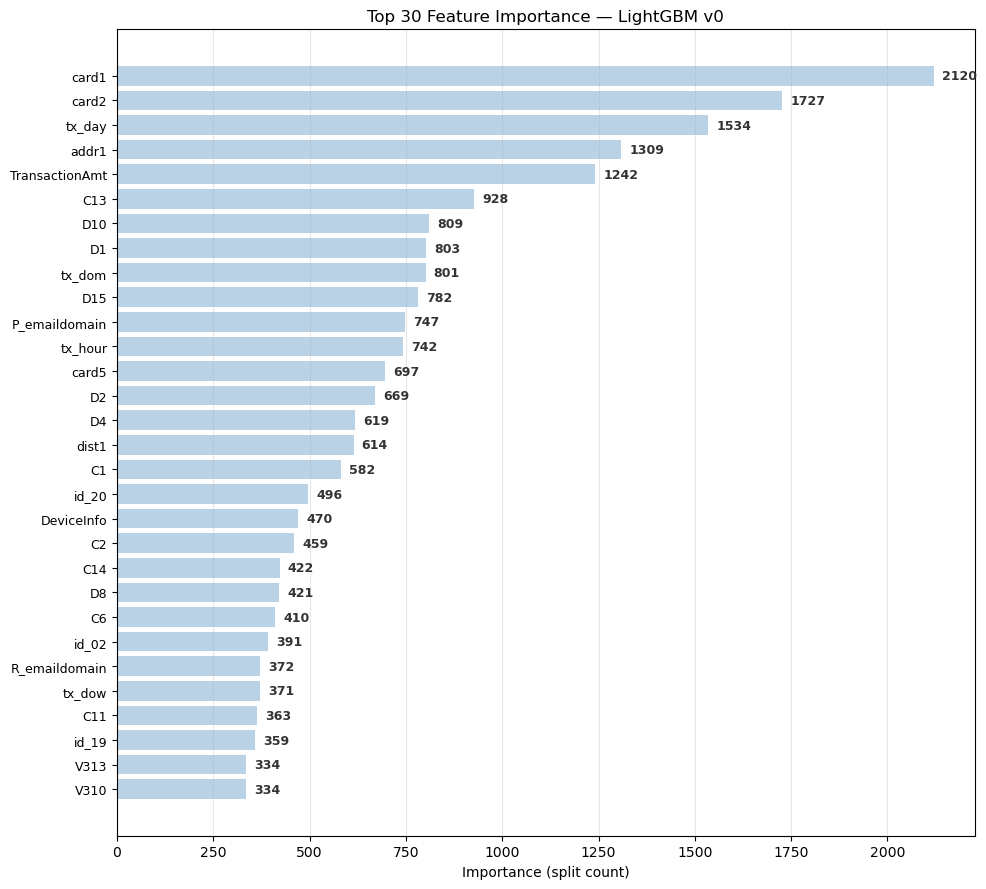

In [9]:
from evaluate_v0 import plot_feature_importance

imp_df = plot_feature_importance(model, X_train.columns.tolist(), top_n=30)


## Step 8 — Final Evaluation on Frozen TEST
**Run once — after all development decisions are made.**
test.parquet was never used during training, early stopping, or threshold selection.
This is the unbiased estimate of real-world performance.


TEST EVALUATION (final — unbiased)
EVALUATION RESULTS
   ROC AUC:  0.895320
   PR AUC:   0.503294
   Threshold: 0.5

   Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    114044
           1       0.81      0.32      0.46      4064

    accuracy                           0.97    118108
   macro avg       0.89      0.66      0.72    118108
weighted avg       0.97      0.97      0.97    118108



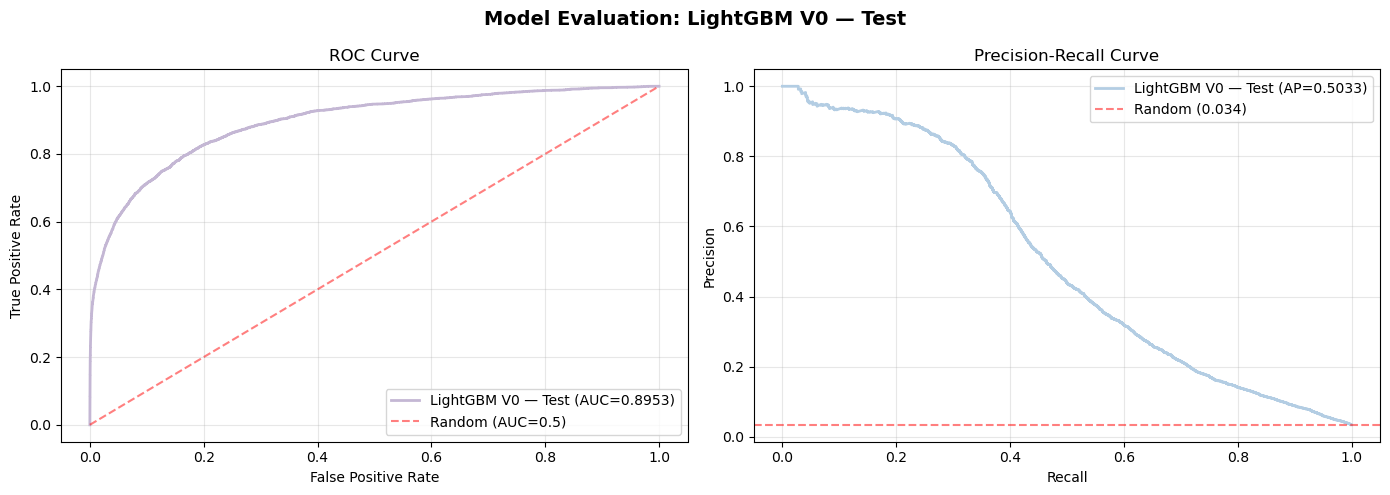

In [10]:
y_pred_test = model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("TEST EVALUATION (final — unbiased)")
print("=" * 60)
test_metrics = compute_metrics(y_test, y_pred_test)
plot_roc_pr(y_test, y_pred_test, model_name="LightGBM V0 — Test")


## Step 9 — Metrics Tracking

In [ ]:
import json

baseline_metrics = {
    "version"       : "baseline_v0",
    "val_roc_auc"   : round(val_metrics["roc_auc"],  6),
    "val_pr_auc"    : round(val_metrics["pr_auc"],   6),
    "test_roc_auc"  : round(test_metrics["roc_auc"], 6),
    "test_pr_auc"   : round(test_metrics["pr_auc"],  6),
    "best_iteration": model.best_iteration_,
    "eval_set"      : "val=middle 20%, test=last 20% of orig_full_train",
}
print("Baseline metrics:", json.dumps(baseline_metrics, indent=2))


Baseline metrics: {
  "version": "baseline_v0",
  "val_roc_auc": 0.931409,
  "val_pr_auc": 0.625989,
  "test_roc_auc": 0.89532,
  "test_pr_auc": 0.503294,
  "best_iteration": 315,
  "eval_set": "val=middle 20%, test=last 20% of orig_full_train"
}


: 

---
---
# Baseline V0 — Conclusions

## Final Metrics

| Set | ROC AUC | PR AUC |
|-----|---------|--------|
| Val (development) | 0.9314 | 0.6260 |
| **Test (final — unbiased)** | **0.8953** | **0.5033** |

- **Best iteration**: 315 / 3000
- **Features**: 436 raw features, no feature engineering
- **Split**: train = days 1–101 (60%) | val = days 101–141 (20%) | test = days 141–183 (20%)

---

## Why Val and Test Metrics Differ
```
ROC AUC:  0.9314 → 0.8953  (−3.6 pp)
PR AUC:   0.6260 → 0.5033  (−12.3 pp)
```

- The model was trained on days 1–101. 
- Val covers days 101–141, 
- Test covers days 141–183.
- **The further from the training period, the harder it is for the model to generalize —
fraudsters adapt their behavior over time, so later transactions look different from what the model learned.**

- This is **expected, not a bug**. 
- It is exactly why a time-based split is mandatory: a random split would leak future patterns into training and produce artificially optimistic metrics.
- Test ROC AUC 0.8953 / PR AUC 0.5033 is the most unbiased estimate available within this dataset and time window.

PR AUC dropped more than ROC AUC (−12.3 pp vs −3.6 pp) — meaning the model struggles
more to precisely detect fraud on later transactions, even though overall ranking still holds.

---

## Threshold Analysis (on Val)

| Threshold | Precision | Recall | F1    |
|-----------|-----------|--------|-------|
| 0.1       | 52.5%     | 62.4%  | 57.0% |
| **0.2**   | **69.9%** | **51.9%** | **59.6%** |
| 0.3       | 78.6%     | 46.0%  | 58.0% |
| 0.4       | 83.2%     | 42.0%  | 55.8% |
| 0.5       | 86.9%     | 38.4%  | 53.2% |

- Best F1 at threshold **0.2** (59.6%)
- At threshold 0.2: out of 10 flagged transactions — 7 are real fraud (Precision 69.9%),
  out of 10 real frauds — 5 are caught (Recall 51.9%)
- At threshold 0.5: model catches only 38.4% of fraud — too conservative for fraud detection

---

## Key Findings

- **Raw features ceiling**: Test ROC AUC 0.8953 / PR AUC 0.5033 is the baseline V2 must exceed.
- **Card identity dominates**: card1, card2, addr1 in top 4 — without group aggregations the model relies on raw card numbers rather than behavioral patterns. It knows *who* is paying, but not *how* they usually pay.
- **PR AUC is the primary metric**: 3.5% fraud rate makes ROC AUC alone misleading — PR AUC reflects real detection quality on the minority class.
- **Early stopping worked correctly**: best iteration 315 out of 3000 — model did not grossly overfit on train.

---

## V2 Target
Exceed Test ROC AUC **0.8953** and Test PR AUC **0.5033** through feature engineering:
group aggregations, multi-period velocity (3d/7d/30d), delta features, email/device novelty signals.